# Exploration du dataset silver

Ce notebook permet de :
- charger le dataset silver joint RTE + SQR ;
- vérifier sa couverture temporelle et sa qualité ;
- explorer les variables énergétiques journalières ;
- visualiser les composantes PCA de température ;
- préparer la suite pour le modeling.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.options.display.max_columns = 0
sns.set_theme(style="whitegrid")

silver_path = (Path.cwd().parent / "data" / "silver" / "rte_sqr_daily_silver.parquet").resolve()
print(f"Silver path: {silver_path}")

if not silver_path.exists():
    raise FileNotFoundError(
        f"Fichier introuvable: {silver_path}\n"
        "Exécute d'abord src/scripts/bronze_to_silver.py"
    )

Silver path: /home/camille/code/Camille9999/EPSI/M2/EPSI-M2_MSPR/src/data/silver/rte_sqr_daily_silver.parquet


In [14]:
silver_df = pd.read_parquet(silver_path)
silver_df["date"] = pd.to_datetime(silver_df["date"], errors="coerce")
silver_df = silver_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

print(f"Shape: {silver_df.shape}")
display(silver_df.head())

Shape: (4749, 8)


,date,consommation_mw,prevision_j1_mw,prevision_j_mw,production_mw,temp_pc_01,temp_pc_02,temp_pc_03
0,2012-01-01,51060.9375,50427.604167,492.6875,51003.770833,-3.338610,6.849751,5.413269
1,2012-01-02,60379.6875,59781.770833,491.614583,60323.71875,-14.100261,4.370491,0.697807
2,2012-01-03,66141.145833,66589.0625,514.572917,67282.197917,-15.249291,-1.146179,2.822054
3,2012-01-04,67244.270833,66988.541667,546.010417,67532.864583,-15.667742,3.208044,2.546018
4,2012-01-05,66772.395833,67546.875,537.635417,68645.729167,-12.303847,3.125173,5.623418


In [3]:
schema_df = pd.DataFrame({
    "column": silver_df.columns,
    "dtype": [str(dtype) for dtype in silver_df.dtypes],
    "missing_count": silver_df.isna().sum().values,
    "missing_rate": silver_df.isna().mean().values,
})

print("Schéma et valeurs manquantes :")
display(schema_df.sort_values(["missing_rate", "column"], ascending=[False, True]))

Schéma et valeurs manquantes :


,column,dtype,missing_count,missing_rate
1,consommation_mw,Float64,0,0.0
0,date,datetime64[us],0,0.0
2,prevision_j1_mw,Float64,0,0.0
3,prevision_j_mw,Float64,0,0.0
4,production_mw,Float64,0,0.0
5,rte_intervals,Int64,0,0.0
6,temp_pc_01,float32,0,0.0
7,temp_pc_02,float32,0,0.0
8,temp_pc_03,float32,0,0.0


In [4]:
date_summary = pd.DataFrame({
    "metric": ["min_date", "max_date", "n_rows", "n_unique_dates"],
    "value": [
        silver_df["date"].min(),
        silver_df["date"].max(),
        len(silver_df),
        silver_df["date"].nunique(),
    ],
})

expected_dates = pd.date_range(silver_df["date"].min(), silver_df["date"].max(), freq="D")
missing_dates = expected_dates.difference(silver_df["date"])

display(date_summary)
print(f"Nombre de dates manquantes dans l'intervalle: {len(missing_dates)}")
if len(missing_dates) > 0:
    display(pd.DataFrame({"missing_date": missing_dates[:20]}))

,metric,value
0,min_date,2012-01-01 00:00:00
1,max_date,2024-12-31 00:00:00
2,n_rows,4749
3,n_unique_dates,4749


Nombre de dates manquantes dans l'intervalle: 0


In [ ]:
energy_columns = [
    "consommation_mw",
    "prevision_j1_mw",
    "prevision_j_mw",
    "production_mw",
]
pca_columns = [column for column in silver_df.columns if column.startswith("temp_pc_")]

print(f"Colonnes énergie: {energy_columns}")
print(f"Colonnes PCA: {pca_columns}")

Colonnes énergie: ['consommation_mw', 'prevision_j1_mw', 'prevision_j_mw', 'production_mw', 'rte_intervals']
Colonnes PCA: ['temp_pc_01', 'temp_pc_02', 'temp_pc_03']


In [6]:
display(silver_df[energy_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
consommation_mw,4749.0,52745.245611,10777.691366,33032.291667,44609.895833,49377.604167,60540.104167,93180.729167
prevision_j1_mw,4749.0,52674.856667,10766.593901,984.375,44565.625,49318.75,60378.645833,93905.208333
prevision_j_mw,4749.0,247.414763,243.636715,33.145833,92.9375,163.895833,332.96875,3881.0625
production_mw,4749.0,52999.832906,10686.313616,35401.802083,45034.15625,49504.416667,60912.229167,90340.114583
rte_intervals,4749.0,96.0,0.0,96.0,96.0,96.0,96.0,96.0


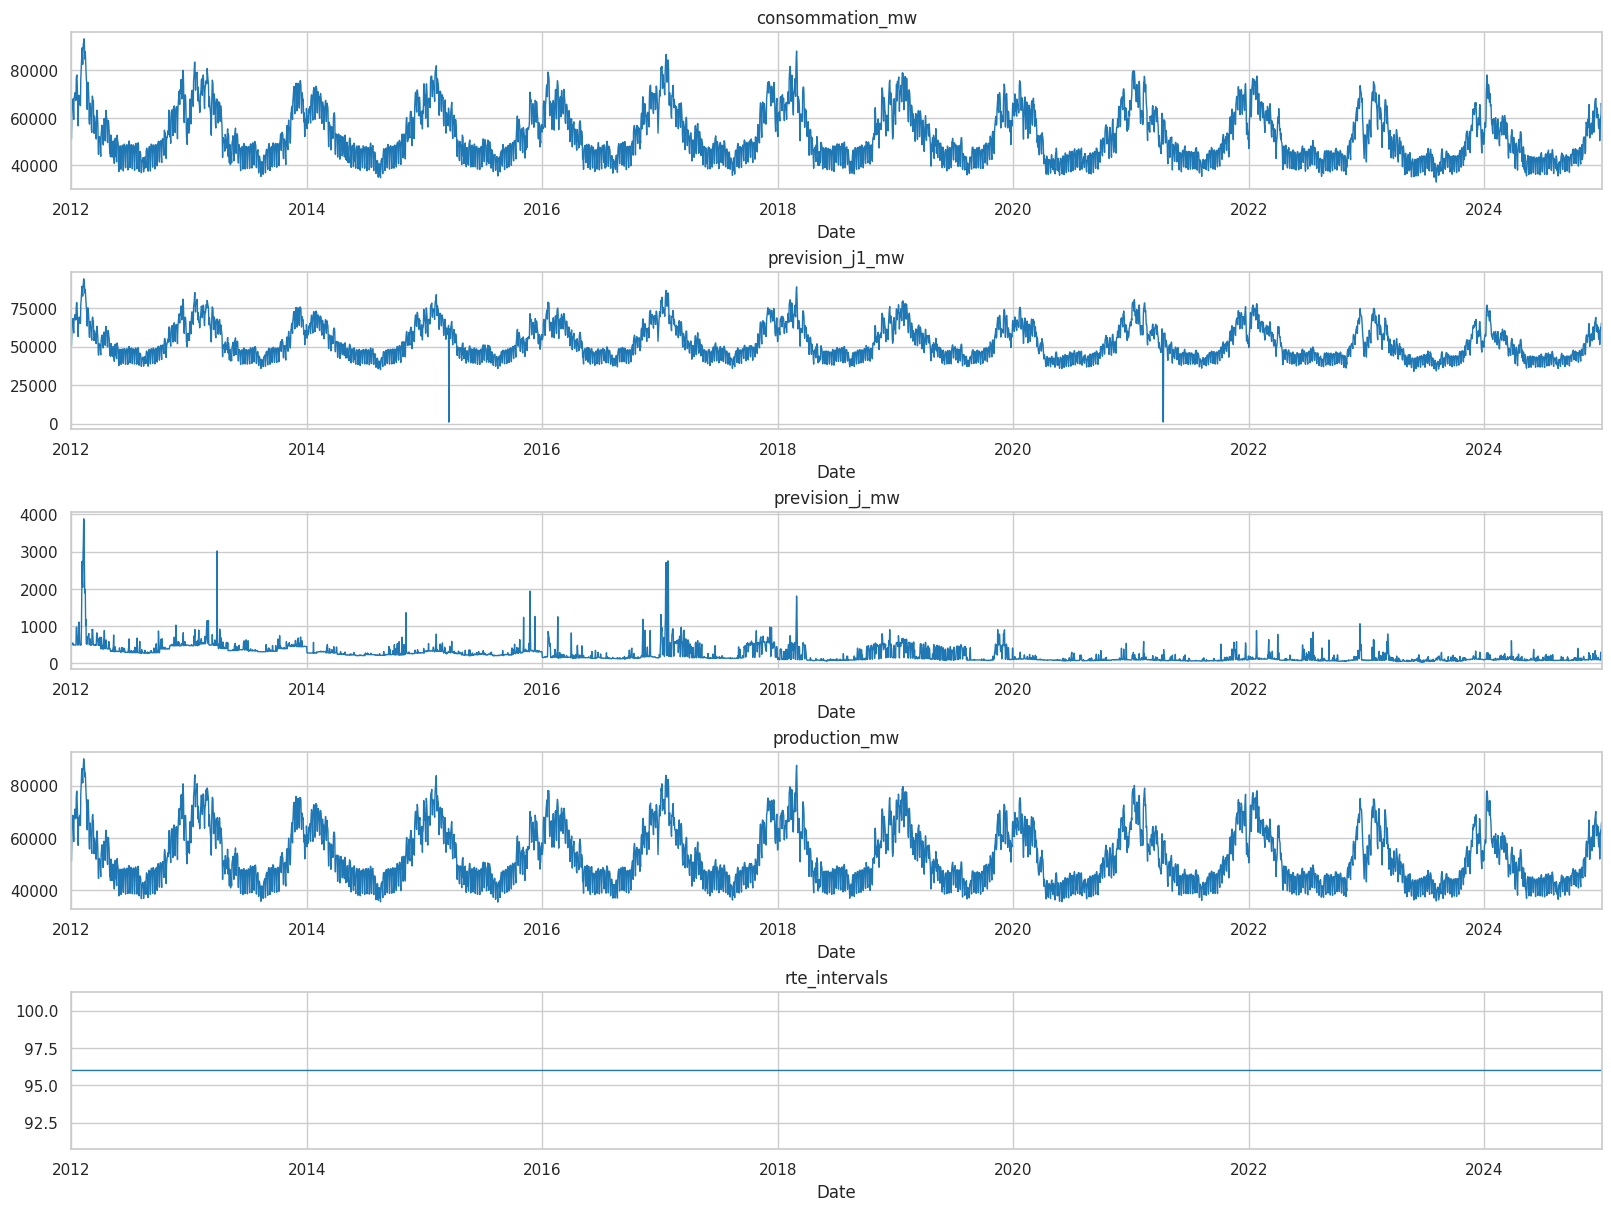

In [7]:
fig, axes = plt.subplots(len(energy_columns), 1, figsize=(16, 12), constrained_layout=True)

for axis, column in zip(axes, energy_columns):
    silver_df.plot(x="date", y=column, ax=axis, linewidth=1.0, legend=False, color="#1f77b4")
    axis.set_title(column)
    axis.set_xlabel("Date")

plt.show()

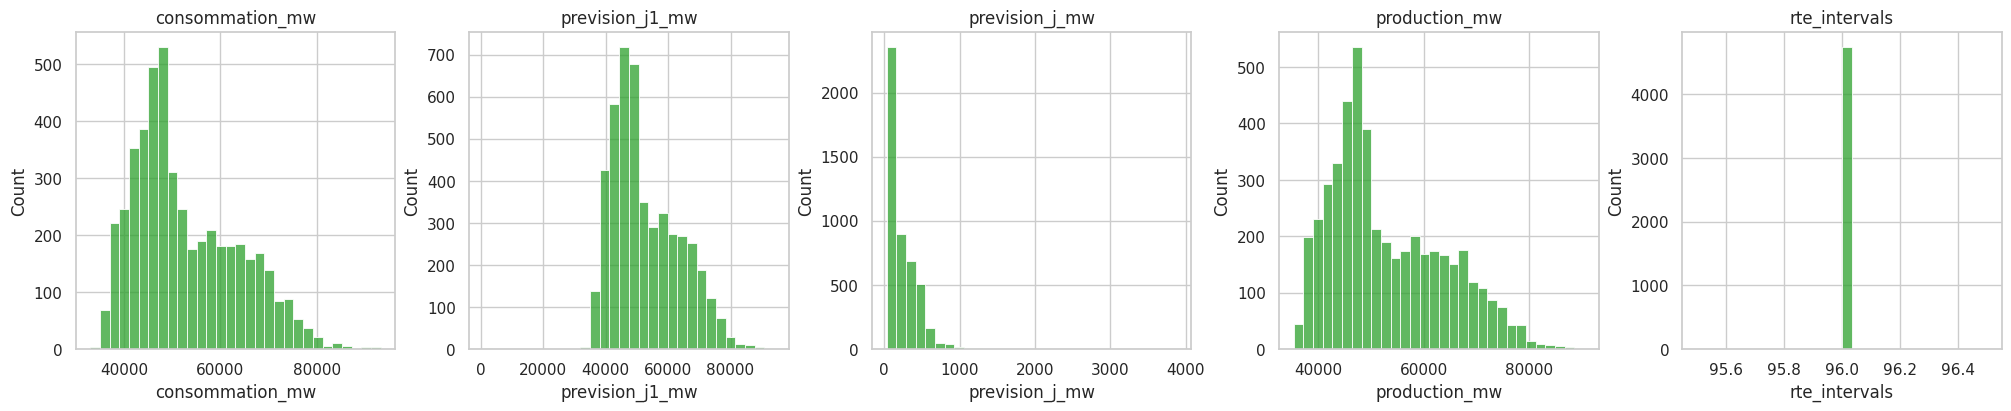

In [8]:
fig, axes = plt.subplots(1, len(energy_columns), figsize=(20, 4), constrained_layout=True)

for axis, column in zip(axes, energy_columns):
    sns.histplot(silver_df[column].dropna(), bins=30, ax=axis, color="#2ca02c")
    axis.set_title(column)

plt.show()

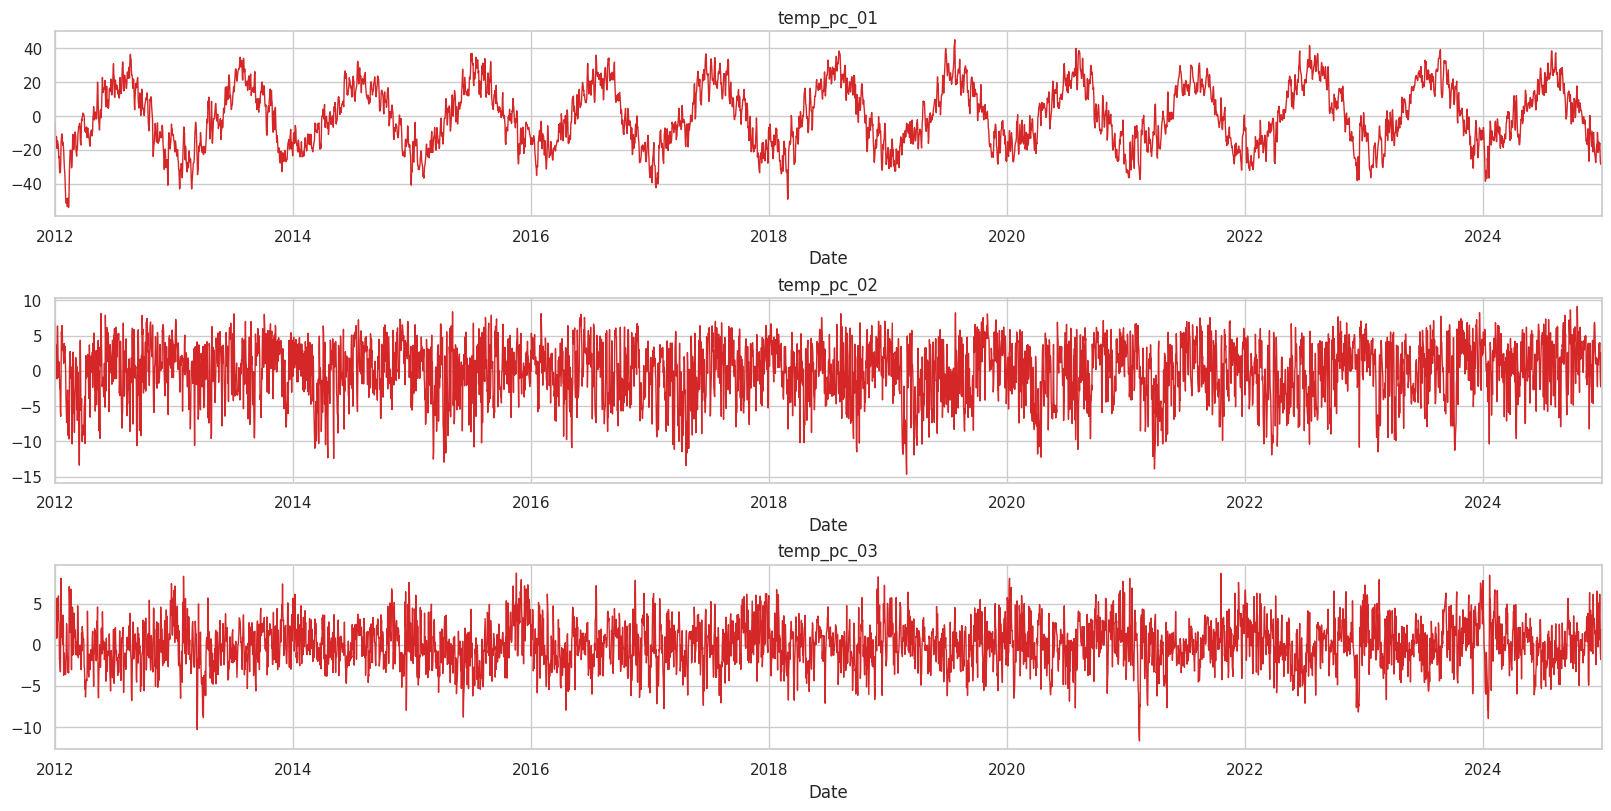

In [9]:
if pca_columns:
    fig, axes = plt.subplots(len(pca_columns), 1, figsize=(16, 8), constrained_layout=True)
    if len(pca_columns) == 1:
        axes = [axes]

    for axis, column in zip(axes, pca_columns):
        silver_df.plot(x="date", y=column, ax=axis, linewidth=1.0, legend=False, color="#d62728")
        axis.set_title(column)
        axis.set_xlabel("Date")

    plt.show()

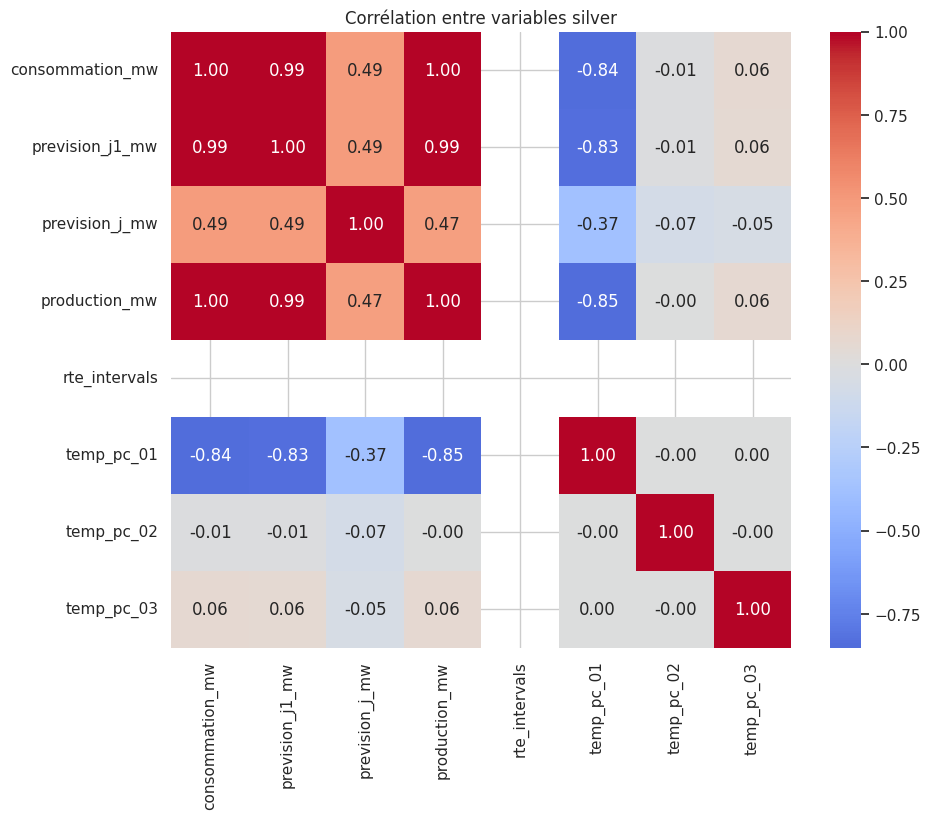

In [10]:
correlation_columns = [column for column in energy_columns + pca_columns if column in silver_df.columns]
correlation_matrix = silver_df[correlation_columns].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Corrélation entre variables silver")
plt.show()

In [11]:
monthly_view = silver_df.copy()
monthly_view["month"] = monthly_view["date"].dt.to_period("M").dt.to_timestamp()
monthly_summary = monthly_view.groupby("month", as_index=False)[energy_columns + pca_columns].mean(numeric_only=True)

display(monthly_summary.head())

,month,consommation_mw,prevision_j1_mw,prevision_j_mw,production_mw,rte_intervals,temp_pc_01,temp_pc_02,temp_pc_03
0,2012-01-01,67871.354167,67622.614247,600.277554,67718.796035,96.0,-20.369802,1.773833,1.587314
1,2012-02-01,78075.826149,77702.33477,1487.613865,76452.686063,96.0,-33.580948,-3.510489,0.677746
2,2012-03-01,57436.323925,57290.272177,588.430108,57197.168011,96.0,-8.860842,-4.761632,-0.086286
3,2012-04-01,54721.597222,55033.211806,490.006944,55053.816667,96.0,-8.694513,-0.048189,-2.256299
4,2012-05-01,47036.105511,46866.112231,353.467742,46778.396169,96.0,6.263137,-0.577763,-0.349955


In [12]:
model_ready_df = silver_df.set_index("date").copy()
print(f"Model-ready shape: {model_ready_df.shape}")
display(model_ready_df.head())

Model-ready shape: (4749, 8)


,consommation_mw,prevision_j1_mw,prevision_j_mw,production_mw,rte_intervals,temp_pc_01,temp_pc_02,temp_pc_03
date,,,,,,,,
2012-01-01,51060.9375,50427.604167,492.6875,51003.770833,96,-3.338610,6.849751,5.413269
2012-01-02,60379.6875,59781.770833,491.614583,60323.71875,96,-14.100261,4.370491,0.697807
2012-01-03,66141.145833,66589.0625,514.572917,67282.197917,96,-15.249291,-1.146179,2.822054
2012-01-04,67244.270833,66988.541667,546.010417,67532.864583,96,-15.667742,3.208044,2.546018
2012-01-05,66772.395833,67546.875,537.635417,68645.729167,96,-12.303847,3.125173,5.623418


## Suites possibles

À partir de ce notebook, tu peux ensuite :
- valider la stabilité temporelle des variables silver ;
- vérifier si les composantes PCA capturent bien la saisonnalité ;
- brancher directement ce dataset dans un notebook de feature engineering ou de modeling.